## Install Required Libraries

In [1]:
! pip install nltk pandas numpy matplotlib seaborn plotly python-bidi arabic-reshaper wordcloud openpyxl tashaphyne tabulate datasets pyarabic huggingface-hub


## Imports and NLTK Downloads

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import re
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize, sent_tokenize
import nltk
import os
from bidi.algorithm import get_display
import arabic_reshaper
from wordcloud import WordCloud
from matplotlib.font_manager import FontProperties, findfont
from collections import Counter
from nltk.util import ngrams
from nltk.stem.isri import ISRIStemmer
from tabulate import tabulate
from datasets import load_dataset
from pyarabic import araby

# Download required NLTK data
nltk.download('punkt')
nltk.download('stopwords')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\hp\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\hp\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

## SECTION 1 - Setup and Helper Functions

In [4]:
def setup_environment():
    try:
        nltk.data.find("tokenizers/punkt")
    except LookupError:
        nltk.download("punkt")
    
    try:
        nltk.data.find("corpora/stopwords")
    except LookupError:
        nltk.download("stopwords")

    sns.set_theme(style="whitegrid")
    plt.rcParams["font.size"] = 12
    plt.rcParams["axes.unicode_minus"] = False

    arabic_fonts = ["Arial", "Amiri", "DejaVu Sans", "Tahoma"]
    font_found = False
    for font in arabic_fonts:
        try:
            font_path = findfont(FontProperties(family=font))
            if os.path.exists(font_path):
                plt.rcParams["font.family"] = font
                print(f"Using Matplotlib font: {font}")
                font_found = True
                break
        except:
            continue
    if not font_found:
        print("Warning: No suitable Arabic font found for Matplotlib.")
        plt.rcParams["font.family"] = "sans-serif"

def get_arabic_font_path() -> str | None:
    arabic_fonts = ["Arial", "Amiri", "DejaVu Sans", "Tahoma"]
    for font in arabic_fonts:
        try:
            font_path = findfont(FontProperties(family=font))
            if os.path.exists(font_path):
                return font_path
        except:
            continue
    print("Warning: No font file found for WordCloud.")
    return None

## SECTION 2 - Data Preparation

In [5]:
# =========================[ CODE 1 — Data Preparation ]=========================
import os
import pandas as pd
from datasets import load_dataset

def setup_directory(data_dir):
    # Create directory if it doesn't exist.
    os.makedirs(data_dir, exist_ok=True)
    return data_dir

def load_datasets(data_dir):
    # Load datasets from local files or Hugging Face.
    file_paths = {
        "by_polishing": os.path.join(data_dir, "by_polishing.parquet"),
        "from_title": os.path.join(data_dir, "from_title.parquet"),
        "from_title_and_content": os.path.join(data_dir, "from_title_and_content.parquet")
    }
    
    if all(os.path.exists(p) for p in file_paths.values()):
        print("Loading dataset from local files...")
        return (
            pd.read_parquet(file_paths["by_polishing"]),
            pd.read_parquet(file_paths["from_title"]),
            pd.read_parquet(file_paths["from_title_and_content"])
        )
    
    print("Downloading dataset from Hugging Face...")
    dataset = load_dataset("KFUPM-JRCAI/arabic-generated-abstracts")
    by_polishing = pd.DataFrame(dataset["by_polishing"])
    from_title = pd.DataFrame(dataset["from_title"])
    from_title_and_content = pd.DataFrame(dataset["from_title_and_content"])
    
    by_polishing.to_parquet(os.path.join(data_dir, "by_polishing.parquet"))
    from_title.to_parquet(os.path.join(data_dir, "from_title.parquet"))
    from_title_and_content.to_parquet(os.path.join(data_dir, "from_title_and_content.parquet"))
    print(f"DataFrames saved as Parquet files in: {data_dir}")
    
    return by_polishing, from_title, from_title_and_content

def reshape_dataframe(df, var_name='category', value_name='text'):
    #Reshape DataFrame using pd.melt.
    return pd.melt(df, var_name=var_name, value_name=value_name)

def save_to_excel(dfs, sheet_names, output_file):
    #Save DataFrames to Excel with different sheets, ensuring Arabic support.
    os.makedirs(os.path.dirname(output_file), exist_ok=True)
    with pd.ExcelWriter(output_file, engine='xlsxwriter') as writer:
        for df, sheet_name in zip(dfs, sheet_names):
            df.to_excel(writer, sheet_name=sheet_name, index=False)
            # Apply Arabic formatting (RTL) to the sheet
            worksheet = writer.sheets[sheet_name]
            worksheet.right_to_left()
            # Set text alignment to right for Arabic text
            format_rtl = writer.book.add_format({'align': 'right'})
            for col_num, col_name in enumerate(df.columns):
                worksheet.set_column(col_num, col_num, None, format_rtl)
    print(f"Data saved to: {output_file} (with Arabic RTL formatting)")

def concatenate_and_save(dfs, output_file):
    #Concatenate DataFrames, save to Excel with Arabic support, and return the result.
    os.makedirs(os.path.dirname(output_file), exist_ok=True)
    concatenated_data = pd.concat(dfs, ignore_index=True)
    with pd.ExcelWriter(output_file, engine='xlsxwriter') as writer:
        concatenated_data.to_excel(writer, sheet_name='Concatenated_Data', index=False)
        # Apply Arabic formatting (RTL) to the sheet
        worksheet = writer.sheets['Concatenated_Data']
        worksheet.right_to_left()
        # Set text alignment to right for Arabic text
        format_rtl = writer.book.add_format({'align': 'right'})
        for col_num, col_name in enumerate(concatenated_data.columns):
            worksheet.set_column(col_num, col_num, None, format_rtl)
    print(f"Concatenated data saved to: {output_file} (with Arabic RTL formatting)")
    return concatenated_data

def DataPreparation():
    #Main function to process datasets and return concatenated DataFrame.
    os.chdir(r"C:\pycharmCodes\NLP\Githup_NLP\Githup")  ############################### Must be updated 
    data_dir = setup_directory(".data/Processed")
    raw_data_dir = setup_directory(".data/raw")

    
    by_polishing, from_title, from_title_and_content = load_datasets(raw_data_dir)
    
    by_polishing_long = reshape_dataframe(by_polishing)
    from_title_and_content_long = reshape_dataframe(from_title_and_content)
    from_title_long = reshape_dataframe(from_title)
    
    dfs = [by_polishing_long, from_title_and_content_long, from_title_long]
    sheet_names = ['by_polishing', 'from_title_and_content', 'from_title']
    save_to_excel(dfs, sheet_names, os.path.join(data_dir, 'reshaped_datasets.xlsx'))
    
    concatenated_df = concatenate_and_save(dfs, os.path.join(data_dir, 'concatenated_data.xlsx'))
    return concatenated_df

# Run the data preparation to get the DataFrame
df = DataPreparation()


Loading dataset from local files...
Data saved to: .data/Processed\reshaped_datasets.xlsx (with Arabic RTL formatting)
Concatenated data saved to: .data/Processed\concatenated_data.xlsx (with Arabic RTL formatting)


## SECTION 3 - Data Exploration and Quality Assessment


================================================= Task 1.3 (Part 1): Inspect Dataset Structure =================================================
Columns and Data Types:
category    object
text        object
dtype: object

Shape: (41940, 2)

=== Data Cleaning ===
Duplicate Rows Before Cleaning: 5399
Duplicate Rows After Cleaning: 0
Rows After Removing Missing Values: (36541, 2)

=== Building 'category_encode' from 'category' ===
'category_encode' counts (1=original_abstract, 0=generated/other):
category_encode
0    33549
1     2992
Name: count, dtype: int64

=== BEFORE cleaning ===
Target counts:
category
original_abstract            8388
allam_generated_abstract     8388
jais_generated_abstract      8388
llama_generated_abstract     8388
openai_generated_abstract    8388
Name: count, dtype: int64
Original vs Generated: {'Original': 8388, 'Generated': 33552}


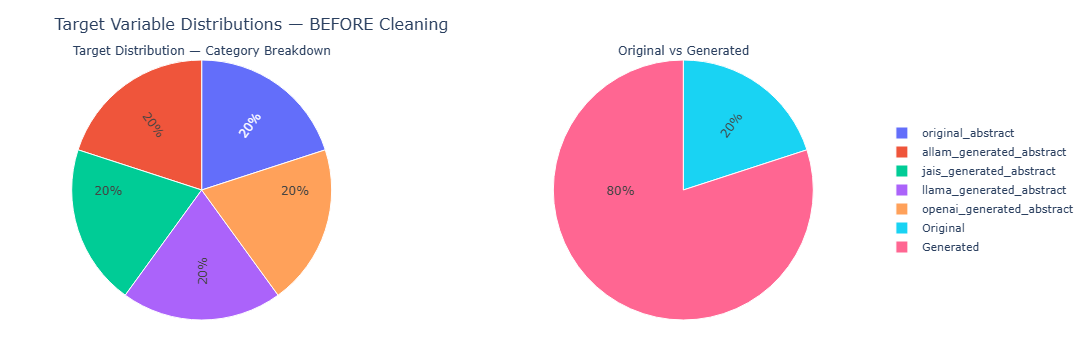


=== AFTER cleaning ===
Original vs Generated (from category_encode): {'Original': 2992, 'Generated': 33549}


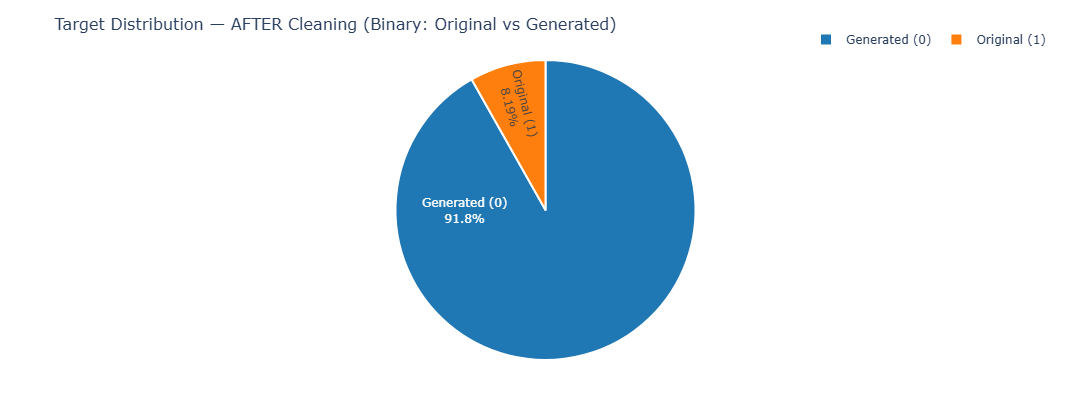


================================================= Task 1.3 (Part 3): Assess Data Quality =================================================

Missing Values:
category    0
text        0
dtype: int64

Converting Columns to String
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41940 entries, 0 to 41939
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   category  41940 non-null  string
 1   text      41940 non-null  string
dtypes: string(2)
memory usage: 655.4 KB
None

Duplicate Rows:
5399

Inconsistencies in Text Columns:
Text columns found: ['category', 'text']

Text Quality Check Results:

Column: 'category'
  Empty strings: 0
  High special character strings: 0
  Short strings (<=3 chars): 0

Column: 'text'
  Empty strings: 0
  High special character strings: 0
  Short strings (<=3 chars): 0

No text quality issues found in any column!


In [6]:
# =========================[ CODE 2 — Task 1.3 EDA + category_encode ]=========================
import re
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots


# ===================== Task 1.3 (Part 1): Load & Inspect =====================|
def inspect_dataset_structure(df: pd.DataFrame):
    # Inspects and prints the basic structure of the dataset.
    print("\n================================================= Task 1.3 (Part 1): Inspect Dataset Structure =================================================")
    print("Columns and Data Types:")
    print(df.dtypes)
    print(f"\n=================================================\nShape: {df.shape}")

# ===================== Helpers: Cleaning (fallback if none exists) =====================
try:
    clean_dataset  # type: ignore
except NameError:
    def clean_dataset(df: pd.DataFrame) -> pd.DataFrame:
        """Remove duplicate rows and missing values, then reset index."""
        print("\n=== Data Cleaning ===")
        print("Duplicate Rows Before Cleaning:", int(df.duplicated().sum()))
        cleaned_df = df.drop_duplicates().dropna().reset_index(drop=True)
        print("Duplicate Rows After Cleaning:", int(cleaned_df.duplicated().sum()))
        print("Rows After Removing Missing Values:", cleaned_df.shape)
        return cleaned_df


# ===================== NEW: Map category -> category_encode (with cleaning flow) =====================
def add_category_encode(df: pd.DataFrame,
                        source_col: str = 'category',
                        target_col: str = 'category_encode') -> pd.DataFrame:
    """
    Create an encoded target from 'category':
      original_abstract -> 1
      anything else     -> 0
    """
    print("\n=== Building 'category_encode' from 'category' ===")
    if source_col not in df.columns:
        raise ValueError(f"Column '{source_col}' not found in DataFrame.")

    s = df[source_col].astype(str).str.strip().str.lower()
    df[target_col] = (s == 'original_abstract') | (s == 'orginal_abstract')
    df[target_col] = df[target_col].astype(int)

    print("'category_encode' counts (1=original_abstract, 0=generated/other):")
    print(df[target_col].value_counts(dropna=False).sort_index())
    return df


# ===================== Helpers: Plotting =====================
def _plot_two_pies_side_by_side(left_vals, left_labels, left_title,
                                right_vals, right_labels, right_title,
                                main_title):
    # Two compact, readable pies side-by-side (no crowded text).
    fig = make_subplots(
        rows=1, cols=2,
        specs=[[{'type': 'domain'}, {'type': 'domain'}]],
        subplot_titles=(left_title, right_title),
        horizontal_spacing=0.14
    )

    fig.add_trace(
        go.Pie(
            labels=left_labels,
            values=left_vals,
            textinfo='percent',
            textposition='inside',
            insidetextorientation='radial',
            hovertemplate='%{label}: %{value} (%{percent})<extra></extra>',
            marker=dict(line=dict(color='white', width=1)),
            showlegend=True,
            sort=False
        ),
        row=1, col=1
    )

    fig.add_trace(
        go.Pie(
            labels=right_labels,
            values=right_vals,
            textinfo='percent',
            textposition='inside',
            insidetextorientation='radial',
            hovertemplate='%{label}: %{value} (%{percent})<extra></extra>',
            marker=dict(line=dict(color='white', width=1)),
            showlegend=True,
            sort=False
        ),
        row=1, col=2
    )

    fig.update_layout(
        title_text=main_title,
        title_font_size=16,
        width=1000, height=340,
        margin=dict(l=20, r=140, t=60, b=20),
        legend=dict(orientation='v',
                    yanchor='middle', y=0.5,
                    xanchor='left',  x=1.02,
                    font=dict(size=11)),
        uniformtext_minsize=9,
        uniformtext_mode='hide'
    )
    for ann in fig['layout']['annotations']:
        ann['font'] = dict(size=12)

    fig.show()


# ===================== Task 1.3 (Part 2): Target Distribution (before/after, side-by-side pies) =====================
def _target_counts_and_title(df: pd.DataFrame):
    """
    Return (counts_series, title_str) with the following priority:
      1) 'label' if exists
      2) 'category_encode' if exists (1=Original, 0=Generated)
      3) 'category' fallback
    """
    if 'label' in df.columns:
        s = df['label'].astype(str)
        return s.value_counts(dropna=False), "Target Distribution — Label"
    elif 'category_encode' in df.columns:
        s = df['category_encode'].map({1: 'Original (1)', 0: 'Generated (0)'})
        return s.value_counts(dropna=False), "Target Distribution — Binary (from category)"
    elif 'category' in df.columns:
        s = df['category'].astype(str)
        return s.value_counts(dropna=False), "Target Distribution — Category Breakdown"
    else:
        raise ValueError("No 'label' or 'category' or 'category_encode' column found.")

def _orig_vs_gen_counts(df: pd.DataFrame):
    """
    Return {'Original': n, 'Generated': m}: 
      - Prefer 'category_encode' if present
      - Else compute from 'category'
      - Else zeros
    """
    if 'category_encode' in df.columns:
        s = df['category_encode'].astype(int)
        original = int(s.sum())
        generated = int(len(s) - s.sum())
        return {'Original': original, 'Generated': generated}

    if 'category' in df.columns:
        s = df['category'].astype(str).str.strip().str.lower()
        original = int((s == 'original_abstract').sum() + (s == 'orginal_abstract').sum())
        generated = int(len(s) - original)
        return {'Original': original, 'Generated': generated}

    return {'Original': 0, 'Generated': 0}

def plot_distributions_before_after(df_before: pd.DataFrame, df_after: pd.DataFrame):
    #Show before/after cleaning distributions: (left) Target label, (right) Original vs Generated.
    # ---------- BEFORE ----------
    target_counts_b, target_title_b = _target_counts_and_title(df_before)
    og_b = _orig_vs_gen_counts(df_before)
    print("\n=== BEFORE cleaning ===")
    print("Target counts:")
    print(target_counts_b)
    print("Original vs Generated:", og_b)

    _plot_two_pies_side_by_side(
        left_vals=target_counts_b.values,
        left_labels=target_counts_b.index.astype(str),
        left_title=target_title_b,
        right_vals=list(og_b.values()),
        right_labels=list(og_b.keys()),
        right_title="Original vs Generated",
        main_title="Target Variable Distributions — BEFORE Cleaning"
    )

    # ---------- AFTER: SINGLE UNIFIED PIE (BINARY ONLY) ----------
    og_a = _orig_vs_gen_counts(df_after)
    print("\n=== AFTER cleaning ===")
    print("Original vs Generated (from category_encode):", og_a)

    # Single pie: Original vs Generated (binary)
    fig = go.Figure(data=[go.Pie(
        labels=['Generated (0)', 'Original (1)'],
        values=[og_a['Generated'], og_a['Original']],
        textinfo='percent+label',
        textposition='inside',
        insidetextorientation='radial',
        hovertemplate='%{label}: %{value} (%{percent})<extra></extra>',
        marker=dict(colors=['#1f77b4', '#ff7f0e'], line=dict(color='white', width=2)),
        sort=False
    )])

    fig.update_layout(
        title_text="Target Distribution — AFTER Cleaning (Binary: Original vs Generated)",
        title_font_size=16,
        width=600, height=400,
        margin=dict(l=40, r=40, t=60, b=40),
        showlegend=True,
        legend=dict(orientation='h', yanchor='bottom', y=1.02, xanchor='right', x=1)
    )
    fig.show()


# ===================== Task 1.3 (Part 3): Data Quality =====================
def check_text_column_quality(df: pd.DataFrame, text_columns: list) -> dict:
    #Checks for inconsistencies in specified text columns.
    text_quality_results = {
        'empty_strings': {},
        'high_special_char_strings': {},
        'short_strings': {}
    }

    special_char_pattern = re.compile(r'[^\u0600-\u06FFa-zA-Z0-9\s]')

    for col in text_columns:
        if col in df.columns:
            s = df[col].astype("string")
            empty_count = s.fillna("").str.strip().eq("").sum()
            text_quality_results['empty_strings'][col] = int(empty_count)
            strings = s.fillna("")
            lengths = strings.str.len().where(lambda x: x > 0, other=1)
            specials = strings.apply(lambda x: len(special_char_pattern.findall(x)))
            high_special_char_count = (specials / lengths > 0.5).sum()
            text_quality_results['high_special_char_strings'][col] = int(high_special_char_count)
            short_string_count = strings.str.strip().str.len().between(1, 3).sum()
            text_quality_results['short_strings'][col] = int(short_string_count)
        else:
            print(f"Warning: Text column '{col}' not found in DataFrame.")

    print("\n=====================================================\nText Quality Check Results:")
    print("=" * 40)
    has_issues = False
    for col in text_columns:
        if col in df.columns:
            print(f"\nColumn: '{col}'")
            print(f"  Empty strings: {text_quality_results['empty_strings'][col]}")
            print(f"  High special character strings: {text_quality_results['high_special_char_strings'][col]}")
            print(f"  Short strings (<=3 chars): {text_quality_results['short_strings'][col]}")
            if (text_quality_results['empty_strings'][col] > 0 or
                text_quality_results['high_special_char_strings'][col] > 0 or
                text_quality_results['short_strings'][col] > 0):
                has_issues = True
    if not has_issues:
        print("\nNo text quality issues found in any column!")
    else:
        print("\nText quality issues found in some columns.")
    return text_quality_results

def assess_data_quality(df: pd.DataFrame) -> dict:
    #Performs a comprehensive assessment of data quality.
    print("\n================================================= Task 1.3 (Part 3): Assess Data Quality =================================================")
    print("\nMissing Values:")
    missing_values = df.isnull().sum()
    print(missing_values)
    print("\nConverting Columns to String")
    cols_to_convert = [c for c in ['category', 'text'] if c in df.columns]
    if cols_to_convert:
        df = df.astype({c: 'string' for c in cols_to_convert})
    print(df.info())
    print("\n=================================================\nDuplicate Rows:")
    duplicates = int(df.duplicated().sum())
    print(duplicates)
    text_columns = df.select_dtypes(include=['object', 'string']).columns.tolist()
    if text_columns:
        print("\nInconsistencies in Text Columns:")
        print(f"Text columns found: {text_columns}")
        text_quality_results = check_text_column_quality(df, text_columns)
    else:
        print("\nNo text columns found for inconsistency check.")
        text_quality_results = {
            'empty_strings': {},
            'high_special_char_strings': {},
            'short_strings': {}
        }
    return {
        'missing_values': missing_values.to_dict(),
        'duplicates': duplicates,
        'text_column_inconsistencies': text_quality_results
    }


# ===================== Run Task 1.3 (in order) =====================
inspect_dataset_structure(df)

# before cleaning (no encoding here)
df_before = df.copy()

# cleaning
df_after = clean_dataset(df_before.copy())

# add category_encode with the cleaning flow
df_after = add_category_encode(df_after, source_col='category', target_col='category_encode')

# plots: before uses raw columns, after will also reflect category_encode
plot_distributions_before_after(df_before, df_after)

# quality on the original df (keep your order)
quality_results = assess_data_quality(df)

## Task 2.1 - Arabic Text Preprocessing Pipeline

In [7]:
# # ======= Minimal fixes only (imports + safe diacritics stripping fallback) =======

# Import core libraries
import os
import re
import pandas as pd
import nltk
from nltk.corpus import stopwords
from nltk.stem.isri import ISRIStemmer
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.font_manager import FontProperties, findfont
# import stanza  # For Arabic lemmatization
import logging  # For error logging

# Try pyarabic for robust diacritics removal; fallback to regex if unavailable
try:
    from pyarabic import araby
    _HAS_PYARABIC = True
except Exception:
    _HAS_PYARABIC = False
    _DIACRITICS_RE = re.compile(r"[\u064B-\u065F\u0670]")

# Set up error logging
logging.basicConfig(filename='preprocessing_errors.log', level=logging.ERROR, 
                    format='%(asctime)s - %(levelname)s - %(message)s')

def setup_environment():
    try:
        nltk.data.find("tokenizers/punkt")
    except LookupError:
        nltk.download("punkt")
    
    try:
        nltk.data.find("corpora/stopwords")
    except LookupError:
        nltk.download("stopwords")

    sns.set_theme(style="whitegrid")
    plt.rcParams["font.size"] = 12
    plt.rcParams["axes.unicode_minus"] = False

    arabic_fonts = ["Arial", "Amiri", "DejaVu Sans", "Tahoma"]
    font_found = False
    for font in arabic_fonts:
        try:
            font_path = findfont(FontProperties(family=font))
            if os.path.exists(font_path):
                plt.rcParams["font.family"] = font
                print(f"Using Matplotlib font: {font}")
                font_found = True
                break
        except:
            continue
    if not font_found:
        print("Warning: No suitable Arabic font found for Matplotlib.")
        plt.rcParams["font.family"] = "sans-serif"

def get_arabic_font_path() -> str | None:
    """
    Searches for a suitable Arabic font file path for WordCloud.
    """
    arabic_fonts = ["Arial", "Amiri", "DejaVu Sans", "Tahoma"]
    for font in arabic_fonts:
        try:
            font_path = findfont(FontProperties(family=font))
            if os.path.exists(font_path):
                return font_path
        except:
            continue
    print("Warning: No font file found for WordCloud.")
    return None

def _strip_tashkeel_safe(text: str) -> str:
    """Use pyarabic.araby if available; otherwise regex fallback."""
    if _HAS_PYARABIC:
        return araby.strip_tashkeel(text)
    return _DIACRITICS_RE.sub("", text)

def arabic_text_preprocessing_pipeline(text: str, stop_words: set) -> str:
    if pd.isna(text) or not isinstance(text, str):
        return ""
    
    # Normalization
    text = re.sub(r"[أإآ]", "ا", text)  # Unify hamza forms
    text = re.sub(r"ى", "ي", text)      # Normalize alif maqsura to yaa
    text = re.sub(r"ة\b", "ه", text)    # Convert taa marbuta to ha
    
    # Remove diacritics (tashkeel)
    text = _strip_tashkeel_safe(text)

    # Remove non-Arabic characters (keeping only letters and spaces)
    text = re.sub(r"[^\u0600-\u06FF\s]", "", text)
    
    # Tokenize and remove stop words
    words = text.split()
    filtered_words = [word for word in words if word not in stop_words and len(word) > 1]
    
    # Stemming using ISRIStemmer
    stemmer = ISRIStemmer()
    stemmed_words = [stemmer.stem(word) for word in filtered_words]
    
    return " ".join(stemmed_words)

import re

def advanced_arabic_text_cleaning(text: str, synonym_dict: dict = None, dialect_dict: dict = None) -> str:
    if not isinstance(text, str) or not text.strip():
        return ""
    # Remove HTML tags
    text = re.sub(r'<[^>]+>', '', text)
    # Remove URLs
    text = re.sub(r'http\S+|www\S+|https\S+', '', text)
    # Remove emails
    text = re.sub(r'\S+@\S+', '', text)
    # Remove numbers
    text = re.sub(r'\d+', '', text)
    # Remove repeated punctuation
    text = re.sub(r'([؟!.,])\1+', r'\1', text)
    # Remove elongation 
    text = re.sub(r'(.)\1{2,}', r'\1', text)
    # Normalize spaces
    text = re.sub(r'\s+', ' ', text).strip()
    # Dialect normalization (if dictionary provided)
    if dialect_dict:
        words = text.split()
        text = " ".join([dialect_dict.get(word, word) for word in words])
    # Synonym replacement (if dictionary provided)
    if synonym_dict:
        words = text.split()
        text = " ".join([synonym_dict.get(word, word) for word in words])
    return text

def arabic_text_lemmatization_pipeline(text: str, stop_words: set) -> str:
    if pd.isna(text) or not isinstance(text, str):
        return ""
    
    # Normalization
    text = re.sub(r"[أإآ]", "ا", text)  # Unify hamza forms
    text = re.sub(r"ى", "ي", text)      # Normalize alif maqsura to yaa
    text = re.sub(r"ة\b", "ه", text)    # Convert taa marbuta to ha
    
    # Remove diacritics (tashkeel)
    text = _strip_tashkeel_safe(text)

    # Remove non-Arabic characters (keeping only letters and spaces)
    text = re.sub(r"[^\u0600-\u06FF\s]", "", text)
    
    # Tokenize and remove stop words
    words = text.split()
    filtered_words = [word for word in words if word not in stop_words and len(word) > 1]
    
    # Lemmatization using Stanza
    try:
        doc = nlp(" ".join(filtered_words))
        lemmatized_words = [word.lemma for sent in doc.sentences for word in sent.words if word.lemma]
    except Exception as e:
        logging.error(f"Error in lemmatization for text: '{text[:50]}...' - {str(e)}")
        lemmatized_words = filtered_words  # Fallback to filtered words if lemmatization fails
    
    return " ".join(lemmatized_words)

# Apply preprocessing pipeline to df
setup_environment()
font_path = get_arabic_font_path()

print(f"\n=================================================\nRows before cleaning: {len(df)}")
df.dropna(subset=['text', 'category'], inplace=True)
df.drop_duplicates(subset=['text'], inplace=True)
print(f"Rows after cleaning: {len(df)}")

print("\n-=================================================Task 2.1: Applying Arabic Text Preprocessing Pipeline =================================================")
print("Preprocessing Steps (processed_text):")
print("1. Check for valid input (return empty string if NaN or not a string).")
print("2. Normalization:")
print("   - Unify hamza forms (أ, إ, آ to ا).")
print("   - Normalize alif maqsura (ى to ي).")
print("   - Convert taa marbuta (ة) at word ends to ha (ه).")
print("3. Remove diacritics (tashkeel).")
print("4. Remove non-Arabic characters, keeping only letters and spaces.")
print("5. Tokenize and remove stop words (using NLTK Arabic stop words).")
print("6. Apply ISRI stemming to reduce words to their roots.")
print("\nLemmatization Steps (lemmatized_text):")
print("1. Same as above for steps 1-5.")
print("2. Apply Stanza lemmatization to reduce words to their grammatical base forms.")
print("\n-=================================================Task 2.2: Applying Advanced Arabic Text Cleaning =================================================")
print("Additional Preprocessing Steps (advanced_cleaned_text):")
print("1. Remove HTML tags ")
print("2. Remove URLs ")
print("3. Remove email addresses")
print("4. Remove numbers ")
print("5. Remove repeated punctuation")
print("6. Remove character elongation ")
print("7. Normalize spaces (remove extra whitespace).")

df["category_name"] = df["category"].apply(
    lambda cat: "Original Abstract" if cat == "original_abstract" else cat.replace("_generated_abstract", "").replace("_", " ").title()
)

stop_words = set(stopwords.words("arabic"))

# CORRECTED ORDER: Advanced cleaning FIRST → then stop words removal
df["temp_cleaned"] = df["text"].apply(advanced_arabic_text_cleaning)
df["processed_text"] = df["temp_cleaned"].apply(lambda x: arabic_text_preprocessing_pipeline(x, stop_words))
df["lemmatized_text"] = df["temp_cleaned"].apply(lambda x: arabic_text_lemmatization_pipeline(x, stop_words))

# Remove temp column
df.drop("temp_cleaned", axis=1, inplace=True)

df.to_csv(
    r"C:\pycharmCodes\NLP\Githup_NLP\Githup\data\Processed\processed_dataset.csv",
    index=False,
    encoding="utf-8-sig"
)

print("=================================================\nProcessed data saved to 'processed_dataset.csv'")

Using Matplotlib font: Arial

Rows before cleaning: 41940
Rows after cleaning: 36525

-=================================================Task 2.1: Applying Arabic Text Preprocessing Pipeline =================================================
Preprocessing Steps (processed_text):
1. Check for valid input (return empty string if NaN or not a string).
2. Normalization:
   - Unify hamza forms (أ, إ, آ to ا).
   - Normalize alif maqsura (ى to ي).
   - Convert taa marbuta (ة) at word ends to ha (ه).
3. Remove diacritics (tashkeel).
4. Remove non-Arabic characters, keeping only letters and spaces.
5. Tokenize and remove stop words (using NLTK Arabic stop words).
6. Apply ISRI stemming to reduce words to their roots.

Lemmatization Steps (lemmatized_text):
1. Same as above for steps 1-5.
2. Apply Stanza lemmatization to reduce words to their grammatical base forms.

-=================================================Task 2.2: Applying Advanced Arabic Text Cleaning ================================

## Task 2.2 (Part 1) - Statistical Analysis

In [8]:
# Minimal, necessary fixes only
from nltk.tokenize import word_tokenize, sent_tokenize
from tabulate import tabulate
import pandas as pd

def calculate_average_word_length(text: str) -> float:
    """Calculates the average word length in a given text."""
    words = word_tokenize(text) if isinstance(text, str) else []
    if not words:
        return 0.0
    return sum(len(word) for word in words) / len(words)

def calculate_average_sentence_length(text: str) -> float:
    """Calculates the average sentence length in a given text."""
    sentences = sent_tokenize(text) if isinstance(text, str) else []
    if not sentences:
        return 0.0
    sentence_lengths = [len(word_tokenize(s)) for s in sentences]
    return sum(sentence_lengths) / len(sentence_lengths)

def calculate_type_token_ratio(text: str) -> float:
    """Calculates the Type-Token Ratio (TTR) for a given text."""
    tokens = word_tokenize(text) if isinstance(text, str) else []
    if not tokens:
        return 0.0
    return len(set(tokens)) / len(tokens)

def perform_statistical_analysis(df: pd.DataFrame):
    """Calculates and prints statistical features of the text."""
    print("\n================================================= Task 2.2 (Part 1): Statistical Analysis =================================================")
    
    # word_count and avg_word_length from processed_text
    df['word_count'] = df['processed_text'].apply(lambda x: len(word_tokenize(x)) if isinstance(x, str) else 0)
    df['avg_word_length'] = df['processed_text'].apply(calculate_average_word_length)
    
    # sentence_count from original text (better sentence boundaries)
    df['sentence_count'] = df['text'].apply(lambda x: len(sent_tokenize(x)) if isinstance(x, str) else 0)
    
    # avoid division by ~0: if sentence_count == 0 -> 0.0
    df['avg_sentence_length'] = df.apply(
        lambda row: (row['word_count'] / row['sentence_count']) if row['sentence_count'] > 0 else 0.0,
        axis=1
    )
    
    # vocabulary richness (TTR) from processed_text
    df['ttr'] = df['processed_text'].apply(calculate_type_token_ratio)

    summary_df = df.groupby('category_name', dropna=False).agg(
        Count=('category_name', 'size'),
        Avg_Word_Length=('avg_word_length', 'mean'),
        Avg_Sentence_Length=('avg_sentence_length', 'mean'),
        Vocabulary_Richness_TTR=('ttr', 'mean')
    ).reset_index()

    print("\n==================================================")
    print("Category Comparison Summary Table")
    print("==================================================")
    print("This table summarizes statistical metrics (count, average word length, average sentence length, and vocabulary richness via Type-Token Ratio) for each category.")
    print(tabulate(summary_df, headers='keys', tablefmt='psql', showindex=False))

# Run statistical analysis on df from Task 2.1
perform_statistical_analysis(df)



================================================= Task 2.2 (Part 1): Statistical Analysis =================================================

Category Comparison Summary Table
This table summarizes statistical metrics (count, average word length, average sentence length, and vocabulary richness via Type-Token Ratio) for each category.
+-------------------+---------+-------------------+-----------------------+---------------------------+
| category_name     |   Count |   Avg_Word_Length |   Avg_Sentence_Length |   Vocabulary_Richness_TTR |
|-------------------+---------+-------------------+-----------------------+---------------------------|
| Allam             |    8388 |           3.22836 |               16.2068 |                  0.708242 |
| Jais              |    8383 |           3.32343 |               16.1783 |                  0.765303 |
| Llama             |    8374 |           3.2598  |               20.1533 |                  0.661531 |
| Openai            |    8388 |        

## Task 2.2 (Part 2) - Visualization

Using font: Arial

# =======================================================================WordClouds=========================================================
Generating word clouds for 5 categories...


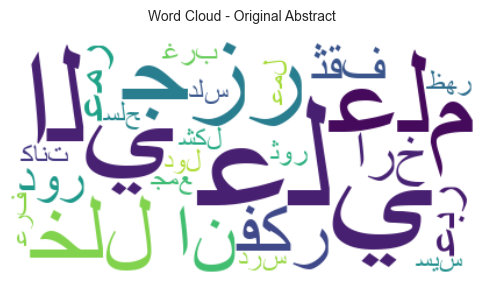

Word cloud saved as 'wordcloud_Original_Abstract.png'


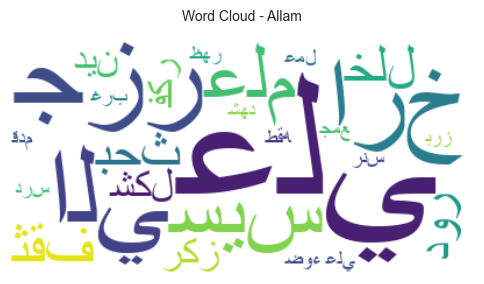

Word cloud saved as 'wordcloud_Allam.png'


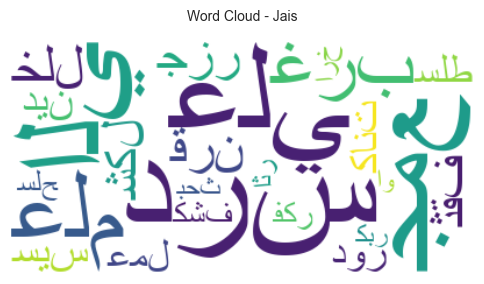

Word cloud saved as 'wordcloud_Jais.png'


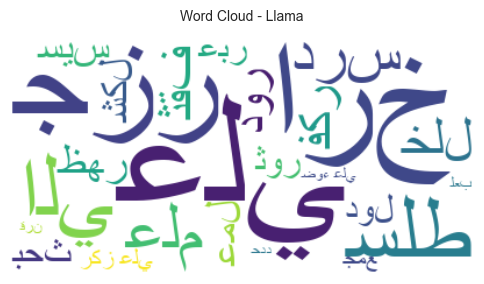

Word cloud saved as 'wordcloud_Llama.png'


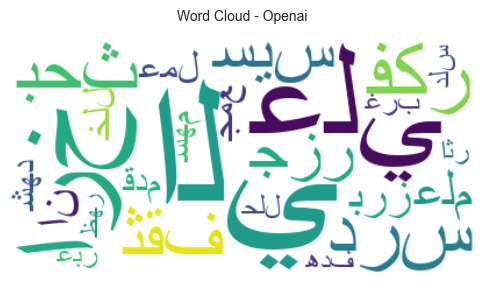

Word cloud saved as 'wordcloud_Openai.png'

# =====================================================================N-Grams for Models ==================================================
Generating n-gram visualizations for 5 categories...


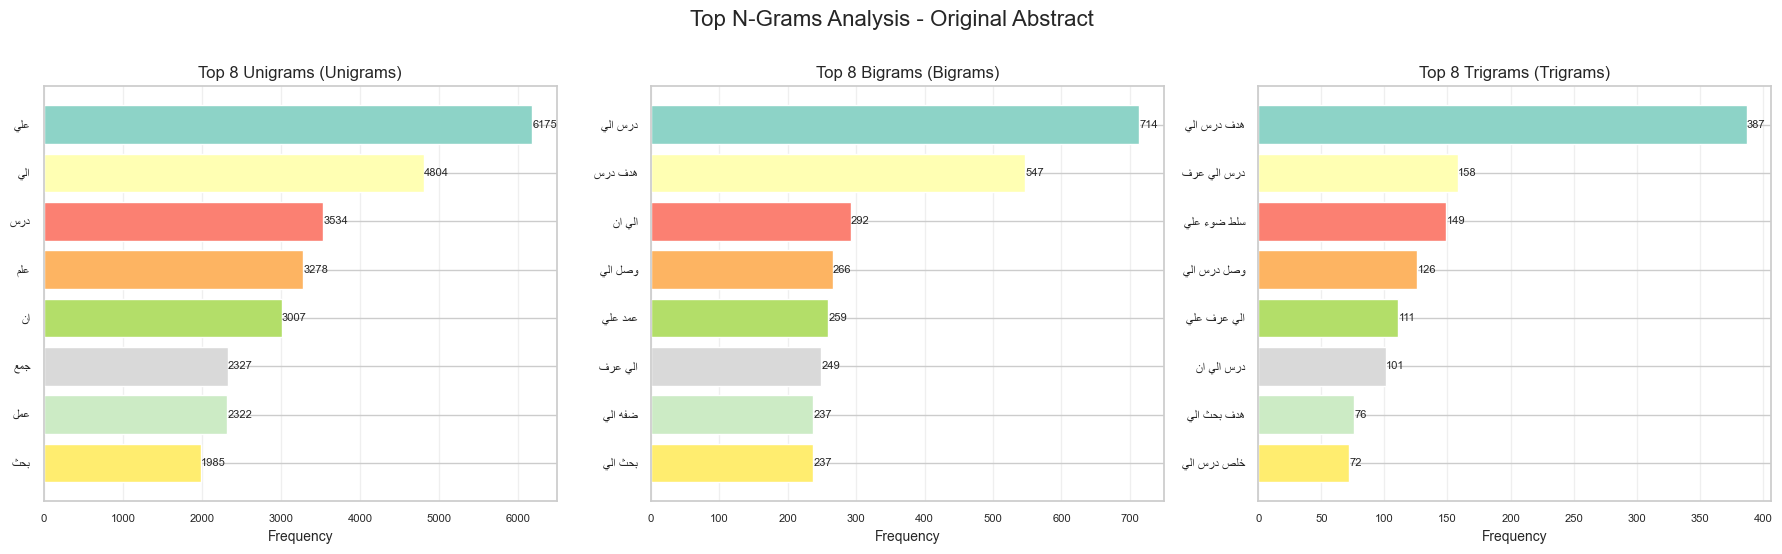

N-gram plot saved as 'ngrams_combined_Original_Abstract.png'


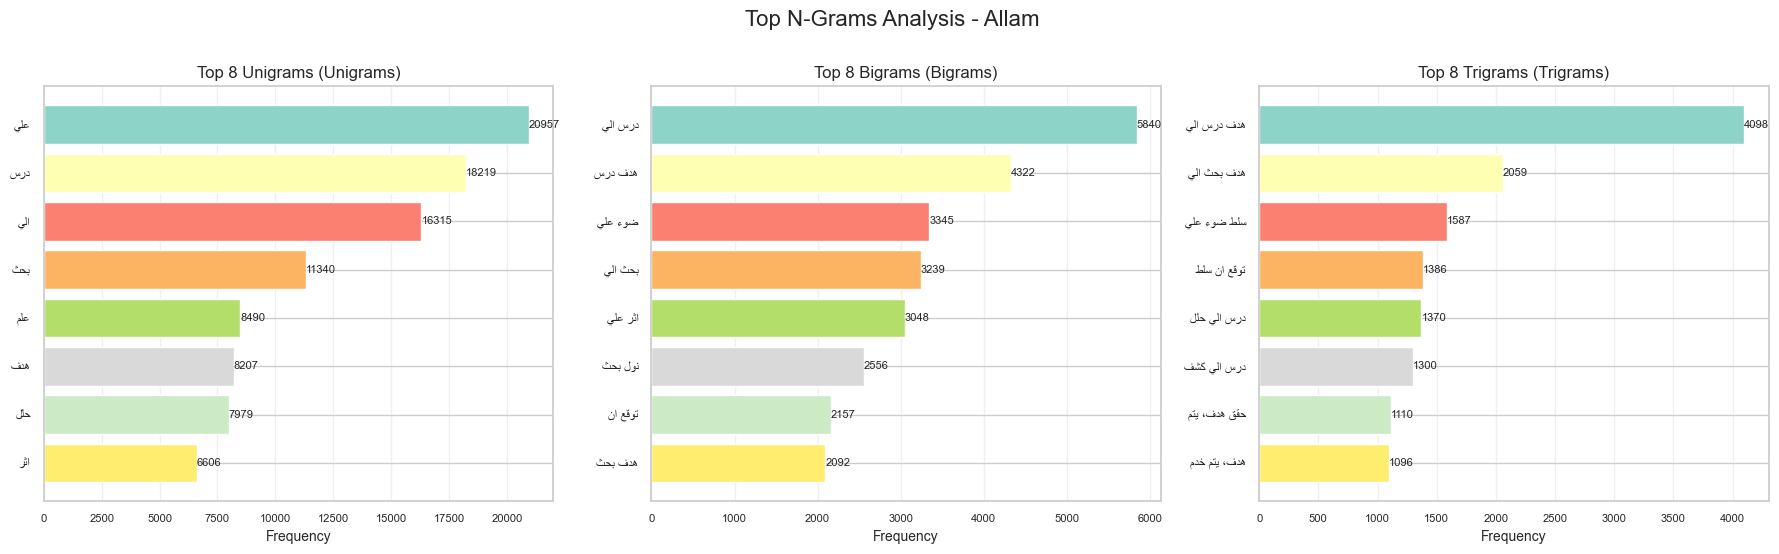

N-gram plot saved as 'ngrams_combined_Allam.png'


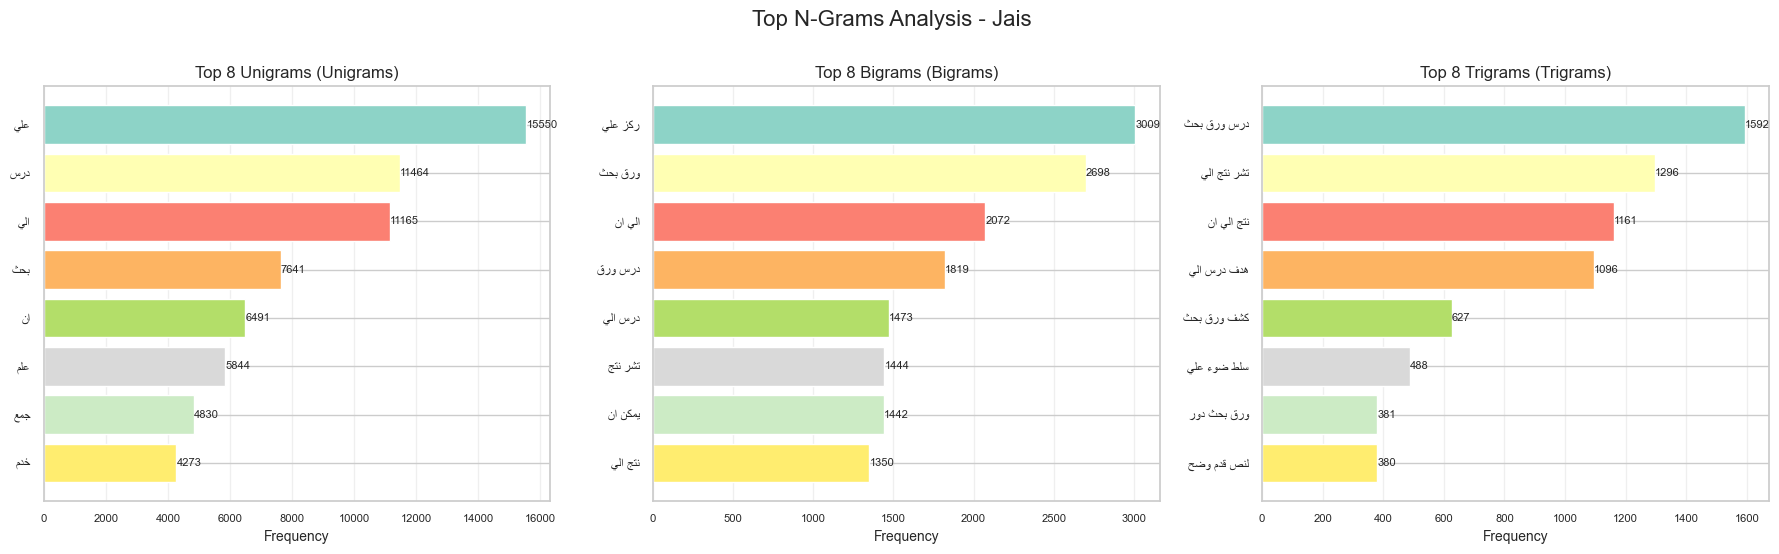

N-gram plot saved as 'ngrams_combined_Jais.png'


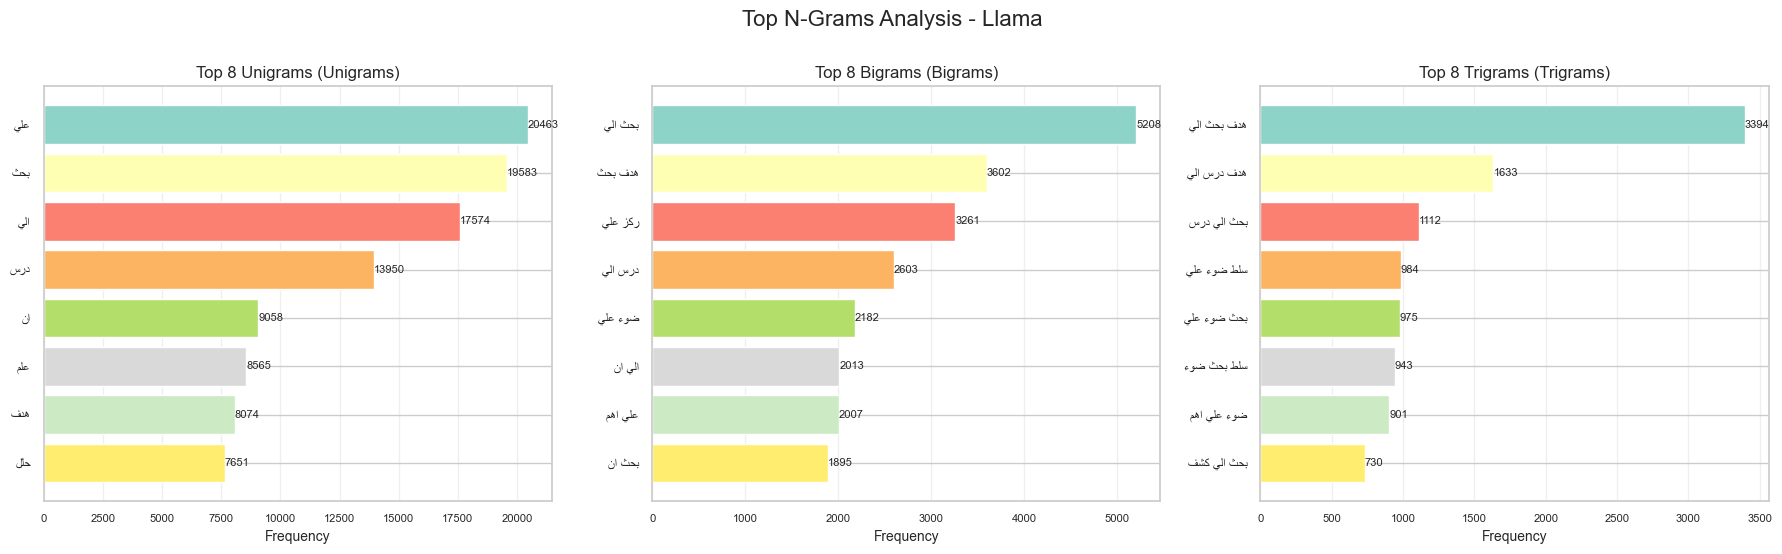

N-gram plot saved as 'ngrams_combined_Llama.png'


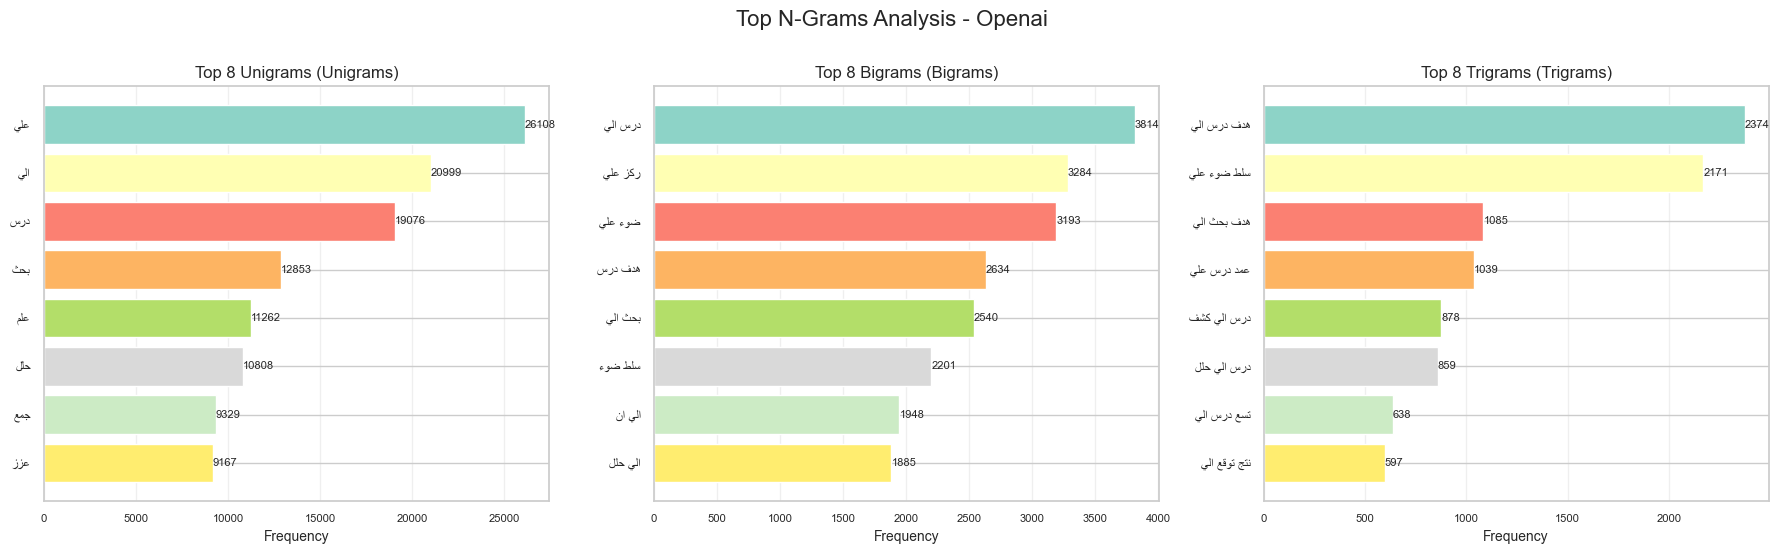

N-gram plot saved as 'ngrams_combined_Openai.png'


In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from bidi.algorithm import get_display
import arabic_reshaper
from wordcloud import WordCloud
from matplotlib.font_manager import FontProperties, findfont
from collections import Counter
from nltk.util import ngrams
import os
import gc

# ==============================================================================
# SETUP AND HELPER FUNCTIONS
# ==============================================================================

def setup_visualization_environment():
    """Configures the plotting environment for Arabic text visualization."""
    sns.set_theme(style="whitegrid")
    plt.rcParams["font.size"] = 12
    plt.rcParams["axes.unicode_minus"] = False

    arabic_fonts = ["Arial", "Amiri", "DejaVu Sans", "Tahoma"]
    for font in arabic_fonts:
        try:
            font_path = findfont(FontProperties(family=font))
            if os.path.exists(font_path):
                plt.rcParams["font.family"] = font
                print(f"Using font: {font}")
                return font_path
        except:
            continue
    
    print("Warning: No suitable Arabic font found.")
    plt.rcParams["font.family"] = "sans-serif"
    return None

def get_arabic_font_path() -> str | None:
    """Searches for a suitable Arabic font file path for WordCloud."""
    arabic_fonts = ["Arial", "Amiri", "DejaVu Sans", "Tahoma"]
    for font in arabic_fonts:
        try:
            font_path = findfont(FontProperties(family=font))
            if os.path.exists(font_path):
                return font_path
        except:
            continue
    print("Warning: No font file found for WordCloud.")
    return None

def reshape_arabic_text(text):
    """Helper function to reshape Arabic text for proper display."""
    reshaped_text = arabic_reshaper.reshape(text)
    return get_display(reshaped_text)

# ==============================================================================
# WORD CLOUD VISUALIZATION
# ==============================================================================

def plot_wordclouds_simple(df: pd.DataFrame, font_path: str | None, max_words: int = 30):
    """
    Generates smaller word clouds for each category with memory optimization.
    """
    if "category_name" not in df.columns or "processed_text" not in df.columns:
        print("Error: Required columns 'category_name' or 'processed_text' not found")
        return

    if not font_path:
        print("Warning: No Arabic font path available. Skipping word clouds to avoid rendering issues.")
        return

    categories = df["category_name"].unique()
    
    print(f"Generating word clouds for {len(categories)} categories...")
    
    for category in categories:
        try:
            # Clear memory before each plot
            gc.collect()
            
            category_texts = df[df["category_name"] == category]["processed_text"].dropna()
            combined_text = " ".join(category_texts)
            
            if not combined_text.strip():
                print(f"No text data for category: {category}")
                continue
            
            # Limit text size to prevent memory issues
            if len(combined_text) > 10000:
                combined_text = combined_text[:10000]
            
            # Create figure with smaller size 
            plt.figure(figsize=(6, 3))
            
            # Generate word cloud with smaller dimensions
            reshaped_text = arabic_reshaper.reshape(combined_text)
            bidi_text = get_display(reshaped_text)
            
            wordcloud = WordCloud(
                font_path=font_path,
                width=400,  
                height=200, 
                background_color="white",
                colormap="viridis",
                max_words=max_words,
                relative_scaling=0.3,
                random_state=42
            ).generate(bidi_text)
            
            plt.imshow(wordcloud, interpolation="bilinear")
            plt.title(reshape_arabic_text(f"Word Cloud - {category}"), fontsize=10, pad=15)  # Reduced fontsize
            plt.axis("off")
            plt.tight_layout()
            
            # Save and show
            filename = f"wordcloud_{category.replace(' ', '_')}.png"
            plt.savefig(filename, dpi=150, bbox_inches="tight", facecolor='white')
            plt.show()
            plt.close()
            
            print(f"Word cloud saved as '{filename}'")
            
        except MemoryError:
            print(f"Memory error generating word cloud for {category}. Skipping...")
            plt.close()
            continue
        except Exception as e:
            print(f"Error generating word cloud for {category}: {str(e)}")
            plt.close()
            continue

# ==============================================================================
# N-GRAM VISUALIZATION
# ==============================================================================

def plot_top_ngrams_combined(df: pd.DataFrame, top_n: int = 8):
    # Generates bar plots of the top n-grams for each category with all three types together.
    if "category_name" not in df.columns or "processed_text" not in df.columns:
        print("Error: Required columns 'category_name' or 'processed_text' not found")
        return

    categories = df["category_name"].unique()
    
    print(f"Generating n-gram visualizations for {len(categories)} categories...")
    
    for category in categories:
        try:
            # Clear memory before each plot
            gc.collect()
            
            category_texts = df[df["category_name"] == category]["processed_text"].dropna()
            
            if category_texts.empty:
                print(f"No data for category: {category}")
                continue
            
            # Extract tokens for this category
            all_tokens = []
            for text in category_texts:
                if isinstance(text, str) and text.strip():
                    tokens = text.split()
                    # Limit tokens to prevent memory issues
                    if len(tokens) > 1000:
                        tokens = tokens[:1000]
                    all_tokens.extend(tokens)
            
            # Create figure with 3 subplots side by side
            fig, axes = plt.subplots(1, 3, figsize=(18, 6))
            fig.suptitle(f"Top N-Grams Analysis - {category}", fontsize=16, y=0.95)
            
            ngram_names = ["Unigrams", "Bigrams", "Trigrams"]
            has_data = False
            
            for n, ax in enumerate(axes, 1):
                try:
                    if len(all_tokens) >= n:
                        # Generate n-grams
                        ngram_counts = Counter(ngrams(all_tokens, n))
                        top_ngrams = ngram_counts.most_common(top_n)
                        
                        if top_ngrams:
                            has_data = True
                            ngrams_list, counts = zip(*top_ngrams)
                            
                            # Prepare labels
                            ngram_labels = []
                            for ng in ngrams_list:
                                arabic_text = " ".join(ng)
                                ngram_labels.append(reshape_arabic_text(arabic_text))
                            
                            # Create horizontal bar plot
                            y_pos = np.arange(len(ngram_labels))
                            bars = ax.barh(y_pos, counts, color=plt.cm.Set3(np.linspace(0, 1, len(ngram_labels))))
                            
                            ax.set_yticks(y_pos)
                            ax.set_yticklabels(ngram_labels, fontsize=9)
                            ax.invert_yaxis()
                            
                            # ADDED: (Unigrams), (Bigrams), (Trigrams)
                            ax.set_title(f"Top {top_n} {ngram_names[n-1]} ({ngram_names[n-1]})", fontsize=12)
                            ax.set_xlabel("Frequency", fontsize=10)
                            
                            # Add value labels
                            for i, (bar, count) in enumerate(zip(bars, counts)):
                                width = bar.get_width()
                                ax.text(width + 0.1, i, str(count), va='center', fontsize=8)
                            
                            ax.grid(axis='x', alpha=0.3)
                            ax.tick_params(axis="x", labelsize=8)
                            
                        else:
                            ax.text(0.5, 0.5, reshape_arabic_text("لا توجد بيانات"), 
                                   ha="center", va="center", fontsize=12, transform=ax.transAxes)
                            ax.set_title(f"{ngram_names[n-1]} ({ngram_names[n-1]})", fontsize=12)
                    else:
                        ax.text(0.5, 0.5, reshape_arabic_text("بيانات غير كافية"), 
                               ha="center", va="center", fontsize=12, transform=ax.transAxes)
                        ax.set_title(f"{ngram_names[n-1]} ({ngram_names[n-1]})", fontsize=12)
                    
                    ax.axis('on')
                    
                except MemoryError:
                    print(f"Memory error generating {n}-grams for {category}. Skipping...")
                    ax.text(0.5, 0.5, "Memory Error", ha="center", va="center", transform=ax.transAxes)
                    continue
                except Exception as e:
                    print(f"Error generating {n}-grams for {category}: {str(e)}")
                    ax.text(0.5, 0.5, "Error", ha="center", va="center", transform=ax.transAxes)
                    continue
            
            if has_data:
                plt.tight_layout(rect=[0, 0.03, 1, 0.95])
                filename = f"ngrams_combined_{category.replace(' ', '_')}.png"
                plt.savefig(filename, dpi=150, bbox_inches="tight", facecolor='white')
                plt.show()
                plt.close()
                print(f"N-gram plot saved as '{filename}'")
            else:
                plt.close(fig)
                print(f"No sufficient data for n-grams in category: {category}")
                    
        except Exception as e:
            print(f"Error processing category {category}: {str(e)}")
            continue

# ==============================================================================
# CALL THE FUNCTIONS
# ==============================================================================

# Setup environment
font_path = setup_visualization_environment()
wordcloud_font_path = get_arabic_font_path()

# Run visualizations
print('\n# =======================================================================WordClouds=========================================================')
plot_wordclouds_simple(df, wordcloud_font_path, max_words=25)
print('\n# =====================================================================N-Grams for Models ==================================================')
plot_top_ngrams_combined(df, top_n=8)

## Task 2.2 (Part 3) - Lexical Analysis


--- Lexical Analysis: Comparing the use of function words, punctuation, and specific terms ---

1. FUNCTION WORD ANALYSIS (Using Original Text)

Top 10 function words for Allam:
   1. في         :  30903
   2. على        :  20757
   3. إلى        :  15723
   4. من         :  15647
   5. هذه        :  10808
   6. هذا        :   8425
   7. أن         :   6148
   8. عن         :   2275
   9. ذلك        :   2023
  10. لا         :    706

Top 10 function words for Jais:
   1. في         :  28008
   2. على        :  15266
   3. من         :  13793
   4. إلى        :  10678
   5. هذه        :   9121
   6. أن         :   6460
   7. هذا        :   4077
   8. ذلك        :   3034
   9. عن         :   2119
  10. قد         :   1050

Top 10 function words for Llama:
   1. في         :  41825
   2. على        :  20115
   3. إلى        :  16789
   4. من         :  16477
   5. أن         :   8850
   6. هذه        :   8787
   7. هذا        :   8708
   8. عن         :   2993
   9. ذلك        :   1764


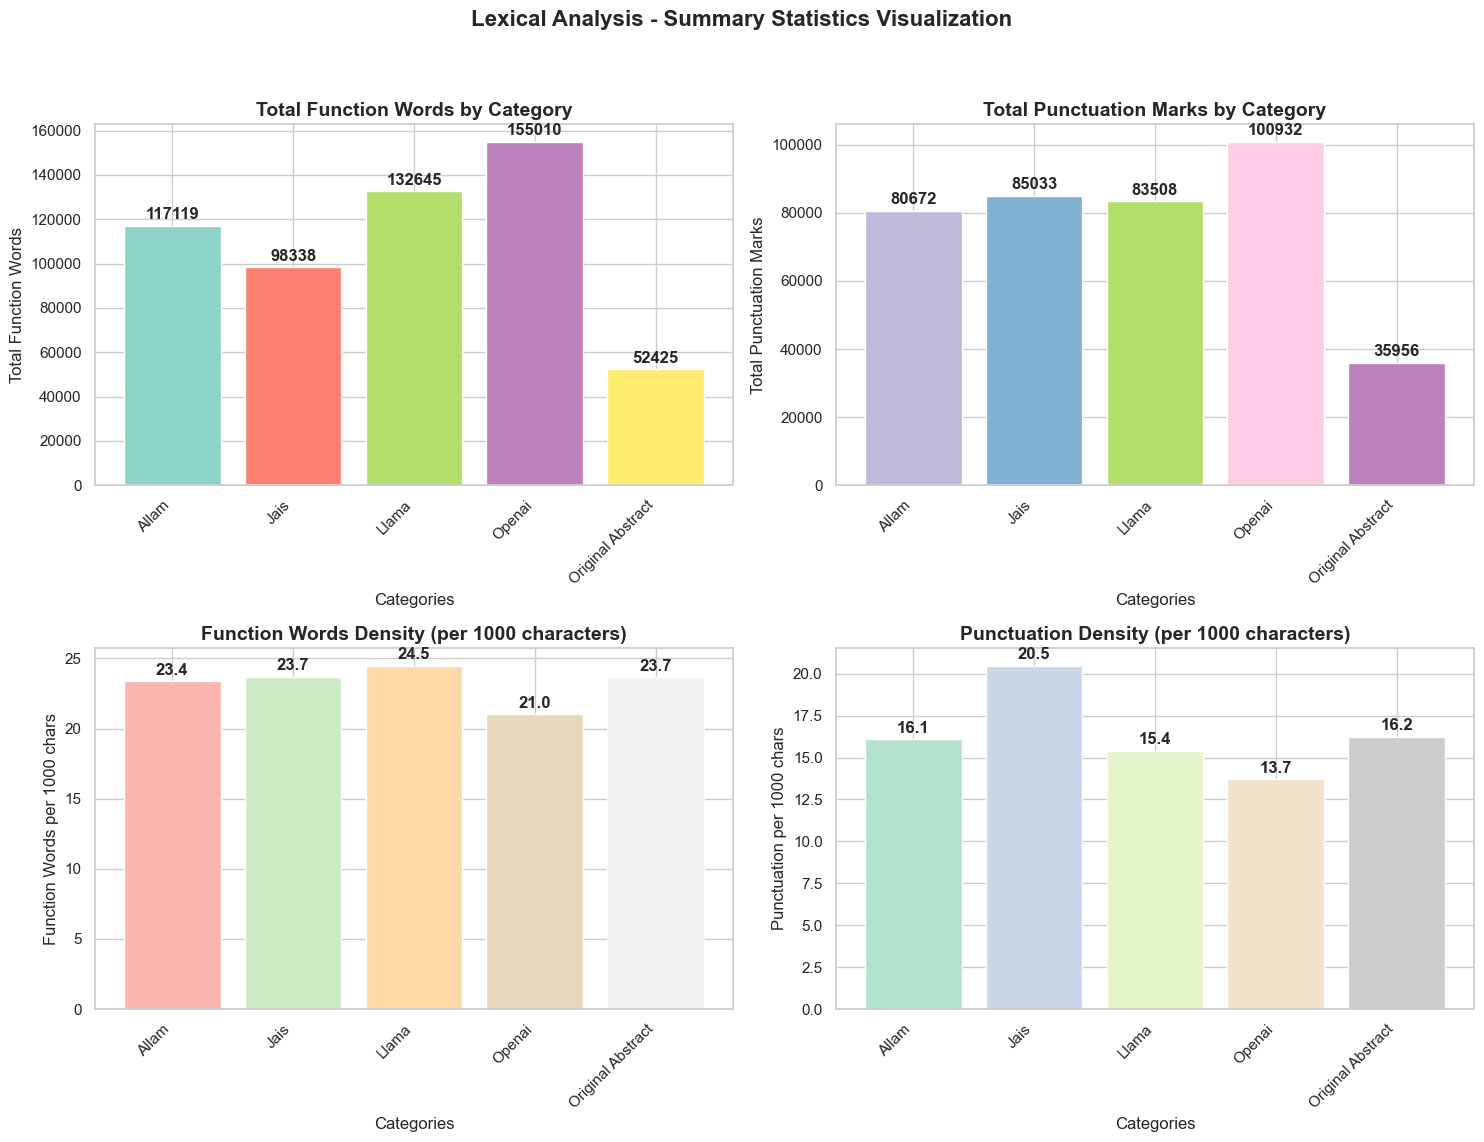


SUMMARY STATISTICS TABLE:
Category                  Func Words   Punctuation  Func/1K chars   Punct/1K chars 
--------------------------------------------------------------------------------
Allam                     117119       80672        23.36           16.09          
Jais                      98338        85033        23.69           20.48          
Llama                     132645       83508        24.49           15.42          
Openai                    155010       100932       21.04           13.70          
Original Abstract         52425        35956        23.68           16.24          

Visualization saved as: 'lexical_analysis_summary.png'


In [9]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from bidi.algorithm import get_display
import arabic_reshaper

def reshape_arabic_text(text):
    """Helper function to reshape Arabic text for proper display."""
    reshaped_text = arabic_reshaper.reshape(text)
    return get_display(reshaped_text)

def format_arabic_text(text):
    """Formats Arabic text for proper display."""
    return str(text)

def get_proper_arabic_function_words():
    """Returns a comprehensive set of true Arabic function words"""
    return {
        # حروف الجر الأساسية
        'من', 'إلى', 'عن', 'على', 'في', 'ب', 'ك', 'ل', 'ت', 'وا',
        # الروابط والعطف
        'و', 'ثم', 'او', 'بل', 'لكن', 'الا', 'لا',
        # أدوات الاستفهام
        'هل', 'ما', 'متى', 'أين', 'كيف', 'لماذا', 
        # أدوات الشرط
        'إذا', 'لو', 'لولا', 'لوما', 'اما',
        # الضمائر المتصلة
        'ها', 'ك', 'ني', 'نا', 'كم', 'كن', 'هم', 'هن',
        # أدوات النفي
        'لا', 'ما', 'لم', 'لن', 'ليس',
        # حروف العلة والربط
        'أن', 'إن', 'كي', 'لان', 'اذ', 'اذا',
        # أخرى
        'قد', 'سوف', 'كل', 'بعض', 'أي', 'هذا', 'هذه', 'ذلك', 'تلك'
    }

def analyze_function_words(texts):
    """Analyze true function words in a list of texts."""
    function_words = get_proper_arabic_function_words()
    
    func_word_counts = {}
    for text in texts:
        if isinstance(text, str):
            words = text.split()
            for word in words:
                # Cleaning punctuation marks from the word
                clean_word = word.strip('.,،:;!?()[]{}"\'')
                if clean_word in function_words:
                    func_word_counts[clean_word] = func_word_counts.get(clean_word, 0) + 1
    return func_word_counts

def analyze_punctuation(texts):
    """Analyze punctuation in a list of texts."""
    punctuation_marks = {'.', '،', ':', '!', '(', ')', '[', ']', '{', '}', ';', '؟', '"', "'"}
    punct_counts = {}
    
    for text in texts:
        if isinstance(text, str):
            for char in text:
                if char in punctuation_marks:
                    punct_counts[char] = punct_counts.get(char, 0) + 1
    return punct_counts

def analyze_specific_terms(texts, terms):
    """Analyze specific terms in a list of texts."""
    term_counts = {term: 0 for term in terms}
    
    for text in texts:
        if isinstance(text, str):
            for term in terms:
                term_counts[term] += text.count(term)
    
    return term_counts

def perform_lexical_analysis(df: pd.DataFrame):
    """Performs and prints lexical analysis results with proper Arabic text formatting."""
    print("\n--- Lexical Analysis: Comparing the use of function words, punctuation, and specific terms ---")
    
    lexical_results = []
    categories = sorted(df['category_name'].unique())
    
    # 1. Function Word Analysis - استخدام النص الأصلي لأن الـ processed_text تم إزالة stop words منه
    print("\n" + "="*80)
    print("1. FUNCTION WORD ANALYSIS (Using Original Text)")
    print("="*80)
    
    all_func_words = set()
    func_word_counts_by_category = {}
    
    for category in categories:
        # استخدام النص الأصلي بدل processed_text لأن الـ function words تم إزالتها
        category_texts = df[df['category_name'] == category]['text']
        func_word_counts = analyze_function_words(category_texts)
        func_word_counts_by_category[category] = func_word_counts
        all_func_words.update(func_word_counts.keys())
        
        # Print top 10 function words for this category
        top_words = sorted(func_word_counts.items(), key=lambda x: x[1], reverse=True)[:10]
        print(f"\nTop 10 function words for {format_arabic_text(category)}:")
        if top_words:
            for i, (word, count) in enumerate(top_words, 1):
                print(f"  {i:2d}. {format_arabic_text(word):<10} : {count:>6}")
        else:
            print("  No function words found.")
    
    # Comparative Function Word Frequencies - Top 10 
    if all_func_words:
        print(f"\nComparative Function Word Frequencies (Top 10 Most Common):")
        print("-" * 60)
        
        # Get the top 10 function words across all categories
        all_func_words_list = sorted(all_func_words, 
                                   key=lambda x: sum(func_word_counts_by_category[cat].get(x, 0) for cat in categories), 
                                   reverse=True)[:10]
        
        for word in all_func_words_list:
            print(f"\n{format_arabic_text(word)}:")
            for cat in categories:
                count = func_word_counts_by_category.get(cat, {}).get(word, 0)
                print(f"  {format_arabic_text(cat):<20}: {count:>6}")
                lexical_results.append({
                    'Category': cat,
                    'Type': 'Function Word',
                    'Term': word,
                    'Count': count
                })
    else:
        print("\nNo function words found in any category.")
    
    # 2. Punctuation Analysis
    print("\n" + "="*80)
    print("2. PUNCTUATION ANALYSIS")
    print("="*80)
    
    all_punctuations = set()
    punct_counts_by_category = {}
    
    for category in categories:
        category_texts = df[df['category_name'] == category]['text']
        punct_counts = analyze_punctuation(category_texts)
        punct_counts_by_category[category] = punct_counts
        all_punctuations.update(punct_counts.keys())
    
    # Print top punctuation marks for each category
    for category in categories:
        punct_counts = punct_counts_by_category.get(category, {})
        top_punct = sorted(punct_counts.items(), key=lambda x: x[1], reverse=True)[:5]
        print(f"\nTop 5 punctuation marks for {format_arabic_text(category)}:")
        if top_punct:
            for i, (punct, count) in enumerate(top_punct, 1):
                print(f"  {i}. '{punct}' : {count}")
        else:
            print("  No punctuation marks found.")
    
    # Comparative Punctuation
    if all_punctuations:
        print(f"\nComparative Punctuation Usage (Top 5 Most Common):")
        print("-" * 50)
        
        # top 5 punctuation for each category
        top_punctuations = sorted(all_punctuations, 
                                key=lambda x: sum(punct_counts_by_category[cat].get(x, 0) for cat in categories), 
                                reverse=True)[:5]
        
        for punct in top_punctuations:
            print(f"\n'{punct}':")
            for cat in categories:
                count = punct_counts_by_category.get(cat, {}).get(punct, 0)
                print(f"  {format_arabic_text(cat):<20}: {count:>6}")
                lexical_results.append({
                    'Category': cat,
                    'Type': 'Punctuation',
                    'Term': punct,
                    'Count': count
                })
    else:
        print("\nNo punctuation marks found in any category.")
    
    # 3. Specific Term Analysis
    print("\n" + "="*80)
    print("3. SPECIFIC TERM ANALYSIS")
    print("="*80)
    
    specific_terms = ['اقتصاد', 'أندلس', 'غزو']
    print(f"Analyzing specific terms: {', '.join([format_arabic_text(t) for t in specific_terms])}")
    
    # Print detailed analysis for each term 
    for term in specific_terms:
        print(f"\n{format_arabic_text(term)}:")
        print("-" * 40)
        for category in categories:
            category_texts = df[df['category_name'] == category]['text']
            term_counts = analyze_specific_terms(category_texts, [term])
            count = term_counts.get(term, 0)
            print(f"  {format_arabic_text(category):<20}: {count:>6} occurrences")
            lexical_results.append({
                'Category': category,
                'Type': 'Specific Term',
                'Term': term,
                'Count': count
            })
    
    # Summary Statistics
    print("\n" + "="*80)
    print("SUMMARY STATISTICS")
    print("="*80)
    
    # Calculate total function words per category
    print("\nTotal Function Words per Category:")
    for category in categories:
        total_func_words = sum(func_word_counts_by_category.get(category, {}).values())
        print(f"  {format_arabic_text(category):<20}: {total_func_words:>6}")
    
    # Calculate total punctuation per category
    print("\nTotal Punctuation Marks per Category:")
    for category in categories:
        total_punct = sum(punct_counts_by_category.get(category, {}).values())
        print(f"  {format_arabic_text(category):<20}: {total_punct:>6}")
    
    # Save all results to CSV
    lexical_df = pd.DataFrame(lexical_results)
    lexical_df.to_csv("lexical_analysis_comparison.csv", index=False, encoding="utf-8-sig")
    print(f"\nLexical analysis comparison saved to 'lexical_analysis_comparison.csv'")

def visualize_summary_statistics(df: pd.DataFrame):
    """Creates visualizations for the summary statistics from lexical analysis."""
    
    print("\n" + "="*80)
    print("CREATING VISUALIZATIONS FOR SUMMARY STATISTICS")
    print("="*80)
    
    categories = sorted(df['category_name'].unique())
    
    # 1. Function Word Analysis - استخدام النص الأصلي
    all_func_words = set()
    func_word_counts_by_category = {}
    
    for category in categories:
        # استخدام النص الأصلي
        category_texts = df[df['category_name'] == category]['text']
        func_word_counts = analyze_function_words(category_texts)
        func_word_counts_by_category[category] = func_word_counts
        all_func_words.update(func_word_counts.keys())
    
    # 2. Punctuation Analysis
    all_punctuations = set()
    punct_counts_by_category = {}
    
    for category in categories:
        category_texts = df[df['category_name'] == category]['text']
        punct_counts = analyze_punctuation(category_texts)
        punct_counts_by_category[category] = punct_counts
        all_punctuations.update(punct_counts.keys())
    
    # Prepare data for visualization
    summary_data = []
    
    for category in categories:
        # Total function words
        total_func_words = sum(func_word_counts_by_category.get(category, {}).values())
        
        # Total punctuation marks
        total_punct = sum(punct_counts_by_category.get(category, {}).values())
        
        # Text length for normalization
        total_text_length = sum(len(str(text)) for text in df[df['category_name'] == category]['text'])
        
        summary_data.append({
            'Category': category,
            'Total_Function_Words': total_func_words,
            'Total_Punctuation': total_punct,
            'Function_Words_per_1000_chars': (total_func_words / total_text_length * 1000) if total_text_length > 0 else 0,
            'Punctuation_per_1000_chars': (total_punct / total_text_length * 1000) if total_text_length > 0 else 0
        })
    
    summary_df = pd.DataFrame(summary_data)
    
    # Create visualizations - Only the 2x2 grid
    fig, axes = plt.subplots(2, 2, figsize=(15, 12))
    fig.suptitle('Lexical Analysis - Summary Statistics Visualization', fontsize=16, fontweight='bold')
    
    # 1. Total Function Words by Category
    axes[0, 0].bar(range(len(categories)), summary_df['Total_Function_Words'], 
                   color=plt.cm.Set3(np.linspace(0, 1, len(categories))))
    axes[0, 0].set_title('Total Function Words by Category', fontsize=14, fontweight='bold')
    axes[0, 0].set_xlabel('Categories')
    axes[0, 0].set_ylabel('Total Function Words')
    axes[0, 0].set_xticks(range(len(categories)))
    axes[0, 0].set_xticklabels([reshape_arabic_text(cat) for cat in categories], rotation=45, ha='right')
    
    # Add value labels on bars
    for i, v in enumerate(summary_df['Total_Function_Words']):
        axes[0, 0].text(i, v + max(summary_df['Total_Function_Words']) * 0.01, 
                       str(int(v)), ha='center', va='bottom', fontweight='bold')
    
    # 2. Total Punctuation by Category
    axes[0, 1].bar(range(len(categories)), summary_df['Total_Punctuation'], 
                   color=plt.cm.Set3(np.linspace(0.2, 0.8, len(categories))))
    axes[0, 1].set_title('Total Punctuation Marks by Category', fontsize=14, fontweight='bold')
    axes[0, 1].set_xlabel('Categories')
    axes[0, 1].set_ylabel('Total Punctuation Marks')
    axes[0, 1].set_xticks(range(len(categories)))
    axes[0, 1].set_xticklabels([reshape_arabic_text(cat) for cat in categories], rotation=45, ha='right')
    
    # Add value labels on bars
    for i, v in enumerate(summary_df['Total_Punctuation']):
        axes[0, 1].text(i, v + max(summary_df['Total_Punctuation']) * 0.01, 
                       str(int(v)), ha='center', va='bottom', fontweight='bold')
    
    # 3. Function Words per 1000 Characters (Normalized)
    axes[1, 0].bar(range(len(categories)), summary_df['Function_Words_per_1000_chars'], 
                   color=plt.cm.Pastel1(np.linspace(0, 1, len(categories))))
    axes[1, 0].set_title('Function Words Density (per 1000 characters)', fontsize=14, fontweight='bold')
    axes[1, 0].set_xlabel('Categories')
    axes[1, 0].set_ylabel('Function Words per 1000 chars')
    axes[1, 0].set_xticks(range(len(categories)))
    axes[1, 0].set_xticklabels([reshape_arabic_text(cat) for cat in categories], rotation=45, ha='right')
    
    # Add value labels on bars
    for i, v in enumerate(summary_df['Function_Words_per_1000_chars']):
        axes[1, 0].text(i, v + max(summary_df['Function_Words_per_1000_chars']) * 0.01, 
                       f'{v:.1f}', ha='center', va='bottom', fontweight='bold')
    
    # 4. Punctuation per 1000 Characters (Normalized)
    axes[1, 1].bar(range(len(categories)), summary_df['Punctuation_per_1000_chars'], 
                   color=plt.cm.Pastel2(np.linspace(0, 1, len(categories))))
    axes[1, 1].set_title('Punctuation Density (per 1000 characters)', fontsize=14, fontweight='bold')
    axes[1, 1].set_xlabel('Categories')
    axes[1, 1].set_ylabel('Punctuation per 1000 chars')
    axes[1, 1].set_xticks(range(len(categories)))
    axes[1, 1].set_xticklabels([reshape_arabic_text(cat) for cat in categories], rotation=45, ha='right')
    
    # Add value labels on bars
    for i, v in enumerate(summary_df['Punctuation_per_1000_chars']):
        axes[1, 1].text(i, v + max(summary_df['Punctuation_per_1000_chars']) * 0.01, 
                       f'{v:.1f}', ha='center', va='bottom', fontweight='bold')
    
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.savefig('lexical_analysis_summary.png', dpi=300, bbox_inches='tight', facecolor='white')
    plt.show()
    
    # Print summary table
    print("\nSUMMARY STATISTICS TABLE:")
    print("="*80)
    print(f"{'Category':<25} {'Func Words':<12} {'Punctuation':<12} {'Func/1K chars':<15} {'Punct/1K chars':<15}")
    print("-"*80)
    
    for _, row in summary_df.iterrows():
        print(f"{reshape_arabic_text(row['Category']):<25} {row['Total_Function_Words']:<12} {row['Total_Punctuation']:<12} {row['Function_Words_per_1000_chars']:<15.2f} {row['Punctuation_per_1000_chars']:<15.2f}")
    
    print(f"\nVisualization saved as: 'lexical_analysis_summary.png'")

# Now call the functions
perform_lexical_analysis(df)
visualize_summary_statistics(df)

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 36525 entries, 0 to 41939
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   category             36525 non-null  object 
 1   text                 36525 non-null  object 
 2   category_name        36525 non-null  object 
 3   processed_text       36525 non-null  object 
 4   lemmatized_text      36525 non-null  object 
 5   word_count           36525 non-null  int64  
 6   avg_word_length      36525 non-null  float64
 7   sentence_count       36525 non-null  int64  
 8   avg_sentence_length  36525 non-null  float64
 9   ttr                  36525 non-null  float64
dtypes: float64(3), int64(2), object(5)
memory usage: 3.1+ MB


In [11]:
df.head()

,category,text,category_name,processed_text,lemmatized_text,word_count,avg_word_length,sentence_count,avg_sentence_length,ttr
0,original_abstract,كثيرا ما ارتبطت المصادر التاريخية في الأندلس خ...,Original Abstract,ربط صدر ارخ دلس خصه كتب رجم هرس رمج وغر درس حي...,ارتبطت المصادر التاريخيه الاندلس خاصه كتب التر...,95,3.094737,3,31.666667,0.726316
1,original_abstract,يعد العامل الثقافي احد ابرز الاسباب التي يعزى ...,Original Abstract,يعد عمل ثقف احد برز سبب يعز سقط دول وحد حتي ان...,يعد العامل الثقافي احد ابرز الاسباب يعزي سقوط ...,105,3.095238,1,105.000000,0.800000
2,original_abstract,شكلت تلك الجهود والمساعي الرائدة التي قام بها ...,Original Abstract,شكل جهد سعي رئد قده ثور خلل رحل اول بحث صدر مو...,شكلت الجهود والمساعي الرائده قاده الثوره خلال ...,172,3.284884,2,86.000000,0.656977
3,original_abstract,يقوم المقال على اشكالية الضرائب الغير شرعية في...,Original Abstract,يقم قال علي شكل ضرب غير شرع خلف رحل دول ربط وح...,يقوم المقال علي اشكاليه الضرائب الغير شرعيه مخ...,95,3.063158,3,31.666667,0.673684
4,original_abstract,تتفق المصادر التاريخية المتوفرة حول موضوع تطور...,Original Abstract,تفق صدر ارخ توفر حول وضع تطر حرك وطن جزر نهي ح...,تتفق المصادر التاريخيه المتوفره حول موضوع تطور...,108,3.175926,1,108.000000,0.888889


In [12]:
df['encoded_category'] = (df['category'] == 'original_abstract').astype(int)

In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 36525 entries, 0 to 41939
Data columns (total 11 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   category             36525 non-null  object 
 1   text                 36525 non-null  object 
 2   category_name        36525 non-null  object 
 3   processed_text       36525 non-null  object 
 4   lemmatized_text      36525 non-null  object 
 5   word_count           36525 non-null  int64  
 6   avg_word_length      36525 non-null  float64
 7   sentence_count       36525 non-null  int64  
 8   avg_sentence_length  36525 non-null  float64
 9   ttr                  36525 non-null  float64
 10  encoded_category     36525 non-null  int64  
dtypes: float64(3), int64(3), object(5)
memory usage: 3.3+ MB


In [14]:
import os
import pandas as pd
folder_path = r"C:\pycharmCodes\NLP\Githup_NLP\Githup\data\Processed"
file_path = os.path.join(folder_path, 'final_dataset_for_modeling.csv')
df[['text', 'processed_text','lemmatized_text', 'category', 'encoded_category']].to_csv(file_path, index=False, encoding='utf-8-sig')

In [15]:
# df[['text', 'processed_text','lemmatized_text', 'category', 'encoded_category']].to_csv('final_dataset_for_modeling.csv', index=False, encoding='utf-8-sig')